<a href="https://colab.research.google.com/github/24Chessman/Niramaya/blob/main/Niramaya_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading Dependencies**

In [ ]:
# all necessary imports
import warnings
from decimal import Decimal
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
# ignore warnings generated due to usage of old version of tensorflow
warnings.simplefilter("ignore")

# **Loading the Dataset and Creation of Features and Label**

In [ ]:
# Scrapping and creation of dataset csv is done in a separate program
df_comb = pd.read_csv("dis_sym_dataset_comb.csv")

# creation of features and label for training the models
X = df_comb.iloc[:, 1:]
Y = df_comb.iloc[:, 0:1]

# **Splitting it into Train-Test**

In [ ]:
# splitting data for training the classifiers and testing
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.10)

# **Training the Logistic Regrssion Model**

In [ ]:
import joblib
# LR Classifier
lr = LogisticRegression()
lr = lr.fit(X, Y)
# prediction of labels for the test data
lr_pred = lr.predict(x_test)
acc_lr = round(Decimal(accuracy_score(y_test, lr_pred) * 100), 2)
print(f"Accuracy (LR) : {acc_lr}%")

# Cross Validation Accuracy LR
# performing cross validation with 5 different splits
scores_lr = cross_val_score(lr, X, Y, cv=5)
# mean of cross val score (accuracy)
score = round(Decimal(scores_lr.mean() * 100), 2)
print(f"Cross Validation Accuracy (LR): {score}%")

joblib.dump(lr, "logistic_regression_model.pkl")

print("Model saved successfully!")

Accuracy (LR) : 91.18%
Cross Validation Accuracy (LR): 89.19%
Model saved successfully!


# **Feature Encoder**

In [ ]:
import pandas as pd
import joblib

# Load the original dataset
df = pd.read_csv("dis_sym_dataset_comb.csv")

# Extract all symptom feature names (skip the first column which is the label)
symptom_features = df.columns[1:]

# Save the list of features so you can use it later to encode inputs
joblib.dump(symptom_features, "symptom_features.pkl")

print("Encoder (symptom feature list) saved successfully.")


Encoder (symptom feature list) saved successfully.


# **Sample Testing**

In [ ]:
import pandas as pd
import joblib

# Load dataset
df = pd.read_csv("dis_sym_dataset_comb.csv")
X = df.iloc[:, 1:]
Y = df.iloc[:, 0:1]

# Load model
model = joblib.load("logistic_regression_model.pkl")
print("Model loaded successfully!")

# Make predictions
predictions = model.predict(X)
print("Sample predictions:", predictions[:5])


Model loaded successfully!
Sample predictions: ['Keratoconjunctivitis Sicca (Dry eye syndrome)'
 'Polycystic ovary syndrome (PCOS)' 'Arthritis' 'Abscess' 'Arthritis']


In [ ]:
print("Number of features:", X.shape[1])
print("Feature names:", list(X.columns))


Number of features: 489
Feature names: ['abdominal cramp', 'abdominal distention', 'abnormal behavior', 'abnormal bleeding', 'abnormal sensation', 'abnormally frequent', 'abscess', 'aching', 'acne', 'acquiring drinking alcohol taking lot time', 'affected part turning white', 'anemia', 'anxiety', 'arm', 'attack pain', 'back', 'bacterial infection', 'bad breath', 'bad smelling thin vaginal discharge', 'bad smelling vaginal discharge', 'barky cough', 'belching', 'better sitting worse lying', 'birth baby younger week gestational age', 'bleeding gum', 'bleeding skin', 'blindness', 'blindness one eye', 'blister sunlight', 'bloating', 'blood stool', 'blood urine', 'bloody diarrhea', 'blue', 'bluish skin coloration', 'blurred vision', 'blurry vision', 'body tremor', 'bone pain', 'bowed leg', 'breakdown skeletal muscle', 'breathing problem', 'bruising', 'burning', 'burning redness eye', 'burning stabbing pain', 'burning urination', 'certain thought repeatedly', 'change bowel movement', 'change 

In [ ]:
import pandas as pd
import joblib

# Load the model and dataset
model = joblib.load("logistic_regression_model.pkl")
df = pd.read_csv("dis_sym_dataset_comb.csv")
X = df.iloc[:, 1:]

# Build a zero-filled input with same columns
input_features = pd.DataFrame([[0]*X.shape[1]], columns=X.columns)

# List the symptoms present for the test case
symptoms = ["fever", "fatigue", "coughing"]

# Set the corresponding symptom columns to 1
for symptom in symptoms:
    if symptom in input_features.columns:
        input_features.at[0, symptom] = 1
    else:
        print(f"Warning: '{symptom}' not found in features!")

# Predict the disease
prediction = model.predict(input_features)
print("Predicted Disease:", prediction[0])


Predicted Disease: Influenza


# **Accuracy Graph**

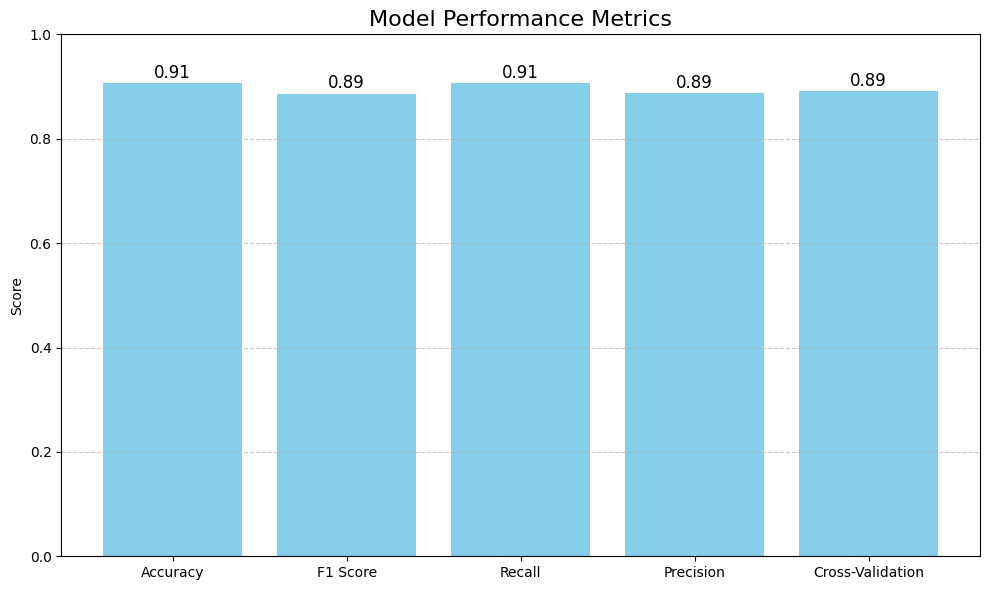

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

# Load model and dataset
model = joblib.load("logistic_regression_model.pkl")
df = pd.read_csv("dis_sym_dataset_comb.csv")

# Prepare features and labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Split for test metrics
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Make predictions
y_pred = model.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
precision = precision_score(y_test, y_pred, average="weighted")
cross_val = cross_val_score(model, X, y, cv=5).mean()

# Round for display
metrics = {
    "Accuracy": round(accuracy, 4),
    "F1 Score": round(f1, 4),
    "Recall": round(recall, 4),
    "Precision": round(precision, 4),
    "Cross-Validation": round(cross_val, 4)
}

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(metrics.keys(), metrics.values(), color='skyblue')
plt.title("Model Performance Metrics", fontsize=16)
plt.ylabel("Score")
plt.ylim(0, 1)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
